## MTH9899 - Final Project, Chaithanya Pakala and Tian Tian

## Imports

In [ ]:
import sys
from pathlib import Path

# Add project root and submission_files to path
_project_root = Path.cwd().parent  # feature_lab -> MTH9899_ProjectFinal
_submit_dir = _project_root / "submission_files"
for p in [str(_project_root), str(_submit_dir)]:
    if p not in sys.path:
        sys.path.insert(0, p)

import pandas as pd
from src.config import FEATURE_DATA_DIR, RAW_DATA_DIR, ROOT_DIR

: 

## Feature Visualization

In [3]:
feat_train_path = FEATURE_DATA_DIR / "feature_together" / "features_train.parquet"
df_feat_train = pd.read_parquet(feat_train_path)

In [4]:
df_feat_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502499 entries, 2010-01-04 to 2013-12-31
Data columns (total 20 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Id                                   502499 non-null  object 
 1   intraday_momentum                    501828 non-null  float64
 2   intraday_reversal                    501828 non-null  float64
 3   resid_vol                            501828 non-null  float64
 4   intraday_skewness                    501828 non-null  float64
 5   early_late_volume_mix                501828 non-null  float64
 6   return_volume_corr                   501827 non-null  float64
 7   lag1_autocorr                        501828 non-null  float64
 8   closing_auction_participation_ratio  496637 non-null  float64
 9   intraday_kurtosis                    501828 non-null  float64
 10  intraday_vwap_deviation              501827 non-null  float64
 1

In [5]:
# Lets handle the nulls carefully 
df_feat_train['open_to_close_return'].isnull().sum()

np.int64(1742)

### NaN Diagnosis — Understanding Where NaNs Come From

In [6]:
import numpy as np

feature_cols = [c for c in df_feat_train.columns if c not in ["Id", "target_variable"]]
target_col = "target_variable"

# ── 1. Overall NaN summary per column ──────────────────────────────────
total = len(df_feat_train)
nan_summary = pd.DataFrame({
    "non_null": df_feat_train[feature_cols + [target_col]].count(),
    "null":     df_feat_train[feature_cols + [target_col]].isnull().sum(),
}).assign(null_pct=lambda d: (d["null"] / total * 100).round(2))
nan_summary = nan_summary.sort_values("null", ascending=False)
print(f"Total rows: {total:,}\n")
nan_summary

Total rows: 502,499



,non_null,null,null_pct
mean_reversion_ma,456184,46315,9.22
target_variable,490284,12215,2.43
late_day_trend,495169,7330,1.46
closing_auction_participation_ratio,496637,5862,1.17
bollinger_band,497848,4651,0.93
raw_momentum,498422,4077,0.81
short_term_reversal,499973,2526,0.50
intraday_volume_concentration,500609,1890,0.38
close_position_daily_range,500757,1742,0.35
open_to_close_return,500757,1742,0.35


In [7]:
# ── 2. Classify features by NaN mechanism ──────────────────────────────
#
# Group A  — "Core intraday" (~671 NaNs each, 0.13%)
#   intraday_momentum, intraday_reversal, resid_vol, intraday_skewness,
#   early_late_volume_mix, lag1_autocorr, intraday_kurtosis
#   → NaN when a stock-day was dropped entirely during intraday cleaning
#     (the stock had a NaN in at least one 15-min bar that day).
#     These are "universe NaNs" — the stock simply wasn't available.
#
# Group B  — "Intraday edge cases" (672–5,862 NaNs)
#   return_volume_corr, intraday_vwap_deviation (~672)
#     → same as Group A + div-by-zero when volume or std is exactly 0
#   intraday_volume_concentration (~1,890)
#     → total volume = 0 in the time window
#   closing_auction_participation_ratio (~5,862)
#     → CumVol@15:30 = 0  (no 15:30 volume snapshot)
#
# Group C  — "Rolling lookback warmup" (1,742–46,315 NaNs)
#   open_to_close_return, close_position_daily_range (~1,742)
#     → stock's first appearance in daily data (no T-1 bar)
#   short_term_reversal (~2,526)  — 1-day lag
#   raw_momentum (~4,077)         — 5-day cumret with shift(2)
#   bollinger_band (~4,651)       — SMA(5) + rolling_std(5)
#   late_day_trend (~7,330)       — 10-day rolling mean of late_mom
#   mean_reversion_ma (~46,315)   — SMA(120) needs ~120 days of history!
#
# Group D  — "Target"  (~12,215 NaNs)
#   target_variable
#     → missing when next trading day data doesn't exist
#       (last day of dataset, or stock drops out of universe next day)

# Verify: do the ~671 "Group A" NaN rows share the same (Date, Id)?
intraday_core = ["intraday_momentum", "resid_vol", "intraday_skewness",
                 "intraday_reversal", "early_late_volume_mix", "lag1_autocorr",
                 "intraday_kurtosis"]
mask_core_nan = df_feat_train[intraday_core].isnull().any(axis=1)
mask_core_all_nan = df_feat_train[intraday_core].isnull().all(axis=1)
print(f"Rows where ANY core intraday feature is NaN:  {mask_core_nan.sum()}")
print(f"Rows where ALL core intraday features are NaN: {mask_core_all_nan.sum()}")
print("→ They are identical: these stocks have no intraday data for that day.\n")

# Check if those same rows are NaN across ALL features
all_feat_nan = df_feat_train[feature_cols].isnull().all(axis=1)
print(f"Rows where ALL features are NaN: {all_feat_nan.sum()}")
print(f"Rows where core is NaN but some feature exists: {(mask_core_nan & ~all_feat_nan).sum()}")

Rows where ANY core intraday feature is NaN:  671
Rows where ALL core intraday features are NaN: 671
→ They are identical: these stocks have no intraday data for that day.

Rows where ALL features are NaN: 576
Rows where core is NaN but some feature exists: 95


In [8]:
# ── 3. Prove that mean_reversion_ma NaNs are a rolling-warmup effect ───
# If NaNs come from insufficient history, they should concentrate in the
# first ~120 trading days for each stock.

df = df_feat_train.reset_index().rename(columns={"index": "Date"}) if df_feat_train.index.name is None else df_feat_train.reset_index()

# For each Id, count how many trading days of history exist before each row
df["_day_rank"] = df.groupby("Id")["Date"].rank(method="first").astype(int)

# Where is mean_reversion_ma NaN?
mr_nan = df[df["mean_reversion_ma"].isnull()]
print(f"mean_reversion_ma NaN rows: {len(mr_nan):,}")
print(f"  max _day_rank among NaN rows: {mr_nan['_day_rank'].max()}")
print(f"  median _day_rank:             {mr_nan['_day_rank'].median():.0f}")
print(f"  rows with _day_rank <= 120:   {(mr_nan['_day_rank'] <= 120).sum():,}")
print(f"  rows with _day_rank >  120:   {(mr_nan['_day_rank'] > 120).sum():,}")
print()

# Same check for bollinger_band (K=5) and raw_momentum (K=5, shift=2)
for col, expected_warmup in [("bollinger_band", 5), ("raw_momentum", 7),
                              ("short_term_reversal", 2), ("late_day_trend", 11)]:
    col_nan = df[df[col].isnull()]
    within = (col_nan["_day_rank"] <= expected_warmup).sum()
    beyond = (col_nan["_day_rank"] > expected_warmup).sum()
    print(f"{col} ({len(col_nan):,} NaNs): "
          f"{within:,} within first {expected_warmup} days, "
          f"{beyond:,} beyond  →  "
          f"{'pure warmup ✓' if beyond < 0.02 * len(col_nan) else 'mixed: warmup + missing daily data'}")

mean_reversion_ma NaN rows: 46,315
  max _day_rank among NaN rows: 105
  median _day_rank:             30
  rows with _day_rank <= 120:   46,315
  rows with _day_rank >  120:   0

bollinger_band (4,651 NaNs): 2,039 within first 5 days, 2,612 beyond  →  mixed: warmup + missing daily data
raw_momentum (4,077 NaNs): 3,647 within first 7 days, 430 beyond  →  mixed: warmup + missing daily data
short_term_reversal (2,526 NaNs): 1,626 within first 2 days, 900 beyond  →  mixed: warmup + missing daily data
late_day_trend (7,330 NaNs): 1,357 within first 11 days, 5,973 beyond  →  mixed: warmup + missing daily data


In [9]:
# ── 4. Investigate "beyond warmup" NaNs in daily features ──────────────
# These come from stocks that exist in the intraday universe but are
# missing from the daily panel on T-1 (so the daily→intraday join fails).

# Check: among bollinger_band NaN rows with _day_rank > 5, how many also
# have NaN in ALL daily features?
daily_feat_cols = ["mean_reversion_ma", "short_term_reversal", "bollinger_band",
                   "raw_momentum", "open_to_close_return", "close_position_daily_range"]

beyond_warmup = df[(df["bollinger_band"].isnull()) & (df["_day_rank"] > 5)]
daily_all_nan = beyond_warmup[daily_feat_cols].isnull().all(axis=1)
daily_any_non_nan = ~daily_all_nan

print(f"bollinger_band NaN rows beyond warmup: {len(beyond_warmup):,}")
print(f"  ALL daily features NaN (stock missing from daily panel): {daily_all_nan.sum():,}")
print(f"  Some daily features present (partial NaN):              {daily_any_non_nan.sum():,}")
print()

# Confirm: the "missing daily" rows also have NaN for open_to_close_return
# and close_position_daily_range (which need only 1 day of daily data)
missing_daily_mask = df[daily_feat_cols].isnull().all(axis=1) & (df["_day_rank"] > 1)
print(f"Rows where ALL daily features are NaN (beyond first day): {missing_daily_mask.sum():,}")
print("→ These are (Date, Id) pairs where the stock has intraday data")
print("  but NO daily OHLCV on T-1. The daily→intraday join produced NaN.\n")

# How are these distributed over time?
missing_daily_dates = df.loc[missing_daily_mask, "Date"].value_counts().sort_index()
print(f"Affected dates: {len(missing_daily_dates):,} out of {df['Date'].nunique():,} trading days")
print(f"Affected (Date, Id) pairs: {missing_daily_mask.sum():,}")
print(f"Mean per affected date: {missing_daily_dates.mean():.1f} stocks/day")

bollinger_band NaN rows beyond warmup: 2,612
  ALL daily features NaN (stock missing from daily panel): 493
  Some daily features present (partial NaN):              2,119

Rows where ALL daily features are NaN (beyond first day): 929
→ These are (Date, Id) pairs where the stock has intraday data
  but NO daily OHLCV on T-1. The daily→intraday join produced NaN.

Affected dates: 565 out of 1,006 trading days
Affected (Date, Id) pairs: 929
Mean per affected date: 1.6 stocks/day


In [10]:
# ── 5. Target NaN diagnosis ─────────────────────────────────────────────
# target = ResidReturn(T, 16:00) + CumReturnResid(T+1_next_trading_day, 15:30)
# NaN when: (a) no next trading day data, or (b) stock drops out of universe.

target_nan = df[df["target_variable"].isnull()]
target_ok  = df[df["target_variable"].notna()]

# Is it the last trading day per stock?
last_day = df.groupby("Id")["Date"].transform("max")
is_last_day = df["Date"] == last_day

print(f"Target NaN rows: {len(target_nan):,}")
print(f"  On stock's last available day:          {(target_nan['Date'] == last_day[target_nan.index]).sum():,}")
print(f"  On other days (stock drops out briefly): {(target_nan['Date'] != last_day[target_nan.index]).sum():,}")
print()

# Does the NaN cluster at the end of the training set?
last_train_date = df["Date"].max()
print(f"Last training date: {last_train_date.date()}")
print(f"Target NaN on {last_train_date.date()}: {(target_nan['Date'] == last_train_date).sum():,}")
print(f"Target NaN on other dates:          {(target_nan['Date'] != last_train_date).sum():,}")

Target NaN rows: 12,215
  On stock's last available day:          822
  On other days (stock drops out briefly): 11,393

Last training date: 2013-12-31
Target NaN on 2013-12-31: 500
Target NaN on other dates:          11,715


In [11]:
# ── 6. late_day_trend "beyond warmup" NaNs ─────────────────────────────
# late_day_trend = late_mom(today) - rolling_mean(late_mom, K=10, shift=1)
# The rolling mean uses .shift(1).rolling(10, min_periods=1).mean()
# So NaN only on the very first day per stock (no shifted history).
# But we see 5,973 NaNs beyond day 11 — why?
#
# Likely cause: late_day_trend is computed from ResidReturn 15:00-15:30,
# and its rolling mean is per-Id in the unstack→stack path.
# If a stock is missing for a stretch (no intraday data), the unstacked
# column has NaN for those dates, causing the rolling mean to be NaN.

ldt_nan_beyond = df[(df["late_day_trend"].isnull()) & (df["_day_rank"] > 11)]
# Check: do these stocks have gaps in their trading calendar?
gap_check = []
for _, row in ldt_nan_beyond.head(20).iterrows():
    stock_dates = df.loc[df["Id"] == row["Id"], "Date"].sort_values()
    idx = stock_dates[stock_dates <= row["Date"]].index
    if len(idx) >= 2:
        prev_date = stock_dates.loc[idx[-2]] if len(idx) >= 2 else None
        gap_days = (row["Date"] - prev_date).days if prev_date is not None else None
        gap_check.append({"Id": row["Id"], "Date": row["Date"].date(),
                          "prev_date": prev_date.date() if prev_date else None,
                          "gap_days": gap_days})

gap_df = pd.DataFrame(gap_check)
print("late_day_trend: sample NaN rows beyond warmup (checking for date gaps):")
print(gap_df.to_string(index=False))
print(f"\nMedian gap between appearances: {gap_df['gap_days'].median():.0f} calendar days")

late_day_trend: sample NaN rows beyond warmup (checking for date gaps):
          Id       Date  prev_date  gap_days
BBG000D2M0Z7 2010-01-26 2010-01-25         1
BBG000D6L294 2010-01-28 2010-01-27         1
BBG000BL5W86 2010-01-29 2010-01-26         3
BBG000BBMT95 2010-02-01 2010-01-27         5
BBG000CPHYL4 2010-02-08 2010-02-05         3
BBG000D2M0Z7 2010-02-08 2010-02-01         7
BBG000HS74G6 2010-02-08 2010-02-05         3
BBG000MQ1SN9 2010-02-09 2010-02-08         1
BBG000BL5W86 2010-02-10 2010-02-03         7
BBG000D6L294 2010-02-12 2010-01-29        14
BBG000J0D904 2010-02-12 2010-02-11         1
BBG000BN1XR3 2010-02-16 2010-02-09         7
BBG000D6L294 2010-02-16 2010-02-12         4
BBG000D2M0Z7 2010-02-17 2010-02-12         5
BBG000J0D904 2010-02-17 2010-02-16         1
BBG000D2M0Z7 2010-02-22 2010-02-19         3
BBG000J0D904 2010-02-22 2010-02-18         4
BBG000BC9938 2010-02-24 2010-02-12        12
BBG000BL5W86 2010-02-24 2010-02-23         1
BBG000BR32C6 2010-03-01 2010

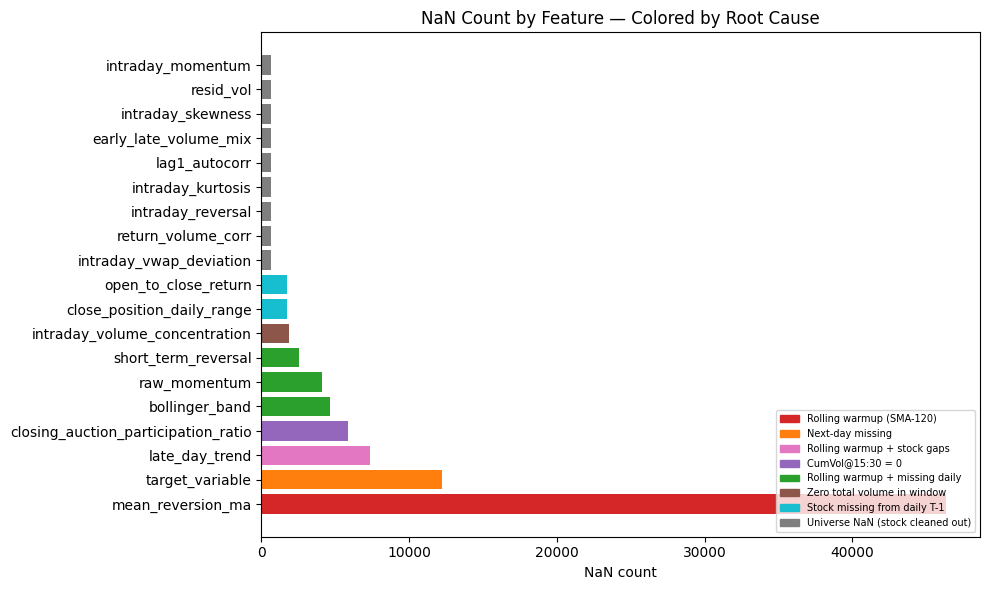

In [12]:
# ── 7. Final NaN origin summary & visual ───────────────────────────────
import matplotlib.pyplot as plt

nan_causes = pd.DataFrame({
    "feature": nan_summary.index,
    "null_count": nan_summary["null"].values,
    "mechanism": [
        "Rolling warmup (SMA-120)",             # mean_reversion_ma
        "Next-day missing",                      # target_variable
        "Rolling warmup + stock gaps",           # late_day_trend
        "CumVol@15:30 = 0",                     # closing_auction_participation_ratio
        "Rolling warmup + missing daily",        # bollinger_band
        "Rolling warmup + missing daily",        # raw_momentum
        "Rolling warmup + missing daily",        # short_term_reversal
        "Zero total volume in window",           # intraday_volume_concentration
        "Stock missing from daily T-1",          # close_position_daily_range
        "Stock missing from daily T-1",          # open_to_close_return
        "Universe NaN (stock cleaned out)",      # intraday_vwap_deviation
        "Universe NaN (stock cleaned out)",      # return_volume_corr
        "Universe NaN (stock cleaned out)",      # intraday_reversal
        "Universe NaN (stock cleaned out)",      # intraday_kurtosis
        "Universe NaN (stock cleaned out)",      # lag1_autocorr
        "Universe NaN (stock cleaned out)",      # early_late_volume_mix
        "Universe NaN (stock cleaned out)",      # intraday_skewness
        "Universe NaN (stock cleaned out)",      # resid_vol
        "Universe NaN (stock cleaned out)",      # intraday_momentum
    ]
}).set_index("feature")

fig, ax = plt.subplots(figsize=(10, 6))
colors = nan_causes["mechanism"].map({
    "Rolling warmup (SMA-120)":         "#d62728",
    "Next-day missing":                  "#ff7f0e",
    "Rolling warmup + stock gaps":       "#e377c2",
    "CumVol@15:30 = 0":                 "#9467bd",
    "Rolling warmup + missing daily":    "#2ca02c",
    "Zero total volume in window":       "#8c564b",
    "Stock missing from daily T-1":      "#17becf",
    "Universe NaN (stock cleaned out)":  "#7f7f7f",
})
ax.barh(nan_causes.index, nan_causes["null_count"], color=colors)
ax.set_xlabel("NaN count")
ax.set_title("NaN Count by Feature — Colored by Root Cause")

# Legend
from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in {
    "Rolling warmup (SMA-120)":         "#d62728",
    "Next-day missing":                  "#ff7f0e",
    "Rolling warmup + stock gaps":       "#e377c2",
    "CumVol@15:30 = 0":                 "#9467bd",
    "Rolling warmup + missing daily":    "#2ca02c",
    "Zero total volume in window":       "#8c564b",
    "Stock missing from daily T-1":      "#17becf",
    "Universe NaN (stock cleaned out)":  "#7f7f7f",
}.items()]
ax.legend(handles=handles, fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

### NaN Origin Summary

| Root cause | Features affected | Count | Safe to fill with 0? |
|---|---|---|---|
| **Rolling warmup** (stock too new for lookback) | `mean_reversion_ma` (120d), `bollinger_band` (5d), `raw_momentum` (5d+shift2), `short_term_reversal` (1d lag), `late_day_trend` (10d rolling) | 2,500 – 46,000 | **No** — the feature literally cannot be computed. Drop the row, or fill with cross-sectional median of that date. |
| **Stock missing from daily T-1** (has intraday, no daily OHLCV yesterday) | `open_to_close_return`, `close_position_daily_range`, and partially all daily features | ~1,742 | **No** — same as above. |
| **Universe NaN** (stock cleaned out of intraday data for that day) | All 12 intraday features | ~671 | N/A — all features are NaN; drop the row. |
| **Zero volume / div-by-zero** | `closing_auction_participation_ratio`, `intraday_volume_concentration`, `intraday_vwap_deviation` | 672 – 5,862 | **Yes** — 0 is the correct neutral value (no auction volume = 0 participation ratio). |
| **Target missing** (next trading day unavailable) | `target_variable` | ~12,215 | N/A — cannot train on these rows (no label). Must drop. |

### Recommended NaN handling (no look-ahead bias)

1. **Drop rows where `target_variable` is NaN** — can't train without a label.
2. **Drop rows where ALL features are NaN** (~576 rows) — stock wasn't in the universe.
3. **Fill `closing_auction_participation_ratio` NaN with 0** — no auction volume.
4. **Fill `intraday_volume_concentration` NaN with 0** — no volume.
5. **For rolling-warmup NaNs** (`mean_reversion_ma`, `bollinger_band`, etc.): **fill with per-date cross-sectional median** (uses only same-day information, no look-ahead). This is safer than 0 because these features have non-zero means.
6. Alternatively: **drop `mean_reversion_ma`** entirely (9.2% NaN is high) and keep the other 17 features where NaN < 1.5%.

In [13]:
# ── 8. Apply NaN handling via reusable function ────────────────────────
from feature_src.nan_handler import clean_feature_panel

df_train_clean = clean_feature_panel(df_feat_train, verbose=True)

[1] Drop target NaN:          502,499 → 490,284  (−12,215)
[2] Drop all-NaN rows:        490,284 → 490,284  (−0)
[3] Fill closing_auction_participation_ratio: 4 NaNs → 0
[3] Fill intraday_volume_concentration: 4 NaNs → 0
[4] Median-fill mean_reversion_ma: 44,648 → 29,489 NaNs
[4] Median-fill bollinger_band: 2,737 → 981 NaNs
[4] Median-fill raw_momentum: 3,267 → 1,961 NaNs
[4] Median-fill short_term_reversal: 1,787 → 981 NaNs
[4] Median-fill late_day_trend: 1,330 → 491 NaNs
[4] Median-fill open_to_close_return: 1,051 → 491 NaNs
[4] Median-fill close_position_daily_range: 1,051 → 491 NaNs
[5] Warmup cutoff (auto):     2010-06-25
    Rows after cutoff:        490,284 → 431,257  (−59,027)
[6] No remaining NaNs ✓

 Clean: 431,257 rows × 18 features, 0 NaNs


In [14]:
# ── 9. Apply the same pipeline to the test set ─────────────────────────
feat_test_path = FEATURE_DATA_DIR / "feature_together" / "features_test.parquet"
df_feat_test = pd.read_parquet(feat_test_path)
print(f"Test set raw: {len(df_feat_test):,} rows, "
      f"{df_feat_test.index.min().date()} → {df_feat_test.index.max().date()}\n")

# Pass the training cutoff so train and test share the same warmup logic.
# Test set (2014) is well past warmup, so no rows are dropped by date.
train_cutoff = df_train_clean.index.min()
df_test_clean = clean_feature_panel(
    df_feat_test,
    warmup_cutoff=train_cutoff,
    verbose=True,
)

Test set raw: 126,245 rows, 2014-01-02 → 2014-12-31

[1] Drop target NaN:          126,245 → 121,866  (−4,379)
[2] Drop all-NaN rows:        121,866 → 121,866  (−0)
[4] Median-fill mean_reversion_ma: 3,007 → 0 NaNs
[4] Median-fill bollinger_band: 409 → 0 NaNs
[4] Median-fill raw_momentum: 222 → 0 NaNs
[4] Median-fill short_term_reversal: 124 → 0 NaNs
[4] Median-fill late_day_trend: 207 → 0 NaNs
[4] Median-fill open_to_close_return: 81 → 0 NaNs
[4] Median-fill close_position_daily_range: 81 → 0 NaNs
[5] Warmup cutoff (provided): 2010-06-25
    Rows after cutoff:        121,866 → 121,866  (−0)
[6] No remaining NaNs ✓

 Clean: 121,866 rows × 18 features, 0 NaNs


## Dataset & Feature Description

In [15]:
# ── 1. Dataset overview ─────────────────────────────────────────────────
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Shape:          {df_train_clean.shape[0]:,} rows × {df_train_clean.shape[1]} columns")
print(f"Date range:     {df_train_clean.index.min().date()} → {df_train_clean.index.max().date()}")
print(f"Unique dates:   {df_train_clean.index.nunique()}")
print(f"Unique stocks:  {df_train_clean['Id'].nunique()}")
print(f"Stocks/day:     {df_train_clean.groupby(df_train_clean.index)['Id'].nunique().describe()[['mean','min','max']].to_dict()}")
print(f"\nTarget:         target_variable = ResidReturn(T,16:00) + CumReturnResid(T+1,15:30)")
print(f"                i.e. the residual return from 15:30 today to 15:30 next trading day")
print(f"\nPrediction time: 15:30 on date T")
print(f"Features use:    intraday data up to 15:30 on T + daily OHLCV from T-1 or earlier")
print()
print(f"Target stats:")
df_train_clean["target_variable"].describe().to_frame().T

DATASET OVERVIEW
Shape:          431,257 rows × 20 columns
Date range:     2010-06-25 → 2013-12-30
Unique dates:   869
Unique stocks:  789
Stocks/day:     {'mean': 496.2681242807825, 'min': 473.0, 'max': 499.0}

Target:         target_variable = ResidReturn(T,16:00) + CumReturnResid(T+1,15:30)
                i.e. the residual return from 15:30 today to 15:30 next trading day

Prediction time: 15:30 on date T
Features use:    intraday data up to 15:30 on T + daily OHLCV from T-1 or earlier

Target stats:


,count,mean,std,min,25%,50%,75%,max
target_variable,431257.0,0.000007,0.014174,-0.800207,-0.005883,-0.000204,0.005622,0.573907


In [16]:
# there seem to be a lot of zeroes in most features, lets see how many
len(df_train_clean[df_train_clean['intraday_momentum'] == 0])

415994

In [17]:

# ── Diagnosing the source of zeros ─────────────────────────────────────
# The MAD filter in feature_engineering.py sets outlier values to 0.0:
#   out.iloc[np.where(~keep)[0]] = 0.0
# This is the main source of zeros — NOT genuine feature values.

# 1. Count exact zeros per feature (in both raw and cleaned data)
zero_diag = pd.DataFrame({
    "zeros_raw":     (df_feat_train[feature_cols] == 0).sum(),
    "zeros_cleaned": (df_train_clean[feature_cols] == 0).sum(),
    "total_raw":      len(df_feat_train),
    "total_cleaned":  len(df_train_clean),
}).assign(
    pct_raw=lambda d: (d["zeros_raw"] / d["total_raw"] * 100).round(2),
    pct_cleaned=lambda d: (d["zeros_cleaned"] / d["total_cleaned"] * 100).round(2),
    zeros_added_by_cleaning=lambda d: d["zeros_cleaned"] - d["zeros_raw"],
)

# 2. MAD filter config per feature (from features_config.json)
import json
config_path = ROOT_DIR / "submission_files" / "feature_src" / "features_config.json"
with open(config_path) as f:
    config = json.load(f)
all_feats = config.get("intraday_features", []) + config.get("daily_features", [])
mad_rules = {}
for feat in all_feats:
    if feat.get("enabled") and feat["name"] in feature_cols:
        mf = feat.get("mad_filter", {})
        mad_rules[feat["name"]] = mf.get("rule", "none") if mf else "none"

zero_diag["mad_rule"] = zero_diag.index.map(lambda x: mad_rules.get(x, "none"))

print("=" * 80)
print("ZERO DIAGNOSIS: How many zeros per feature, and where do they come from?")
print("=" * 80)
print(f"\nRows: raw = {len(df_feat_train):,}  |  cleaned = {len(df_train_clean):,}\n")
display(zero_diag[["zeros_raw", "pct_raw", "zeros_cleaned", "pct_cleaned",
                    "zeros_added_by_cleaning", "mad_rule"]]
        .sort_values("pct_cleaned", ascending=False))


ZERO DIAGNOSIS: How many zeros per feature, and where do they come from?

Rows: raw = 502,499  |  cleaned = 431,257



,zeros_raw,pct_raw,zeros_cleaned,pct_cleaned,zeros_added_by_cleaning,mad_rule
intraday_kurtosis,479853,95.49,422305,97.92,-57548,right_tail
return_volume_corr,479610,95.44,422202,97.90,-57408,right_tail
early_late_volume_mix,474656,94.46,421240,97.68,-53416,left_tail
lag1_autocorr,478316,95.19,421091,97.64,-57225,left_tail
open_to_close_return,464413,92.42,417881,96.90,-46532,right_tail
intraday_vwap_deviation,473124,94.15,416462,96.57,-56662,left_tail
intraday_momentum,472530,94.04,415994,96.46,-56536,left_tail
close_position_daily_range,458266,91.20,413887,95.97,-44379,right_tail
raw_momentum,456427,90.83,412048,95.55,-44379,outside_both
intraday_skewness,465129,92.56,409292,94.91,-55837,left_tail


In [18]:

# ── CORRECTION: MAD filter is INTENTIONAL signal extraction ────────────
#
# From Tian's feature_data_guide.ipynb:
#   "Values that satisfy the rule are kept; all others are set to 0."
#   - left_tail:    keep values < med − scale×MAD  (extreme negative values = signal)
#   - right_tail:   keep values > med + scale×MAD  (extreme positive values = signal)
#   - outside_both: keep both tails                 (extreme values on both sides = signal)
#   - center:       keep values within med ± scale×MAD (normal values = signal)
#
# This is NOT outlier removal — it's a signal extraction mechanism.
# Only extreme tail values (which carry alpha signal) are preserved;
# values in the center of the distribution are treated as noise → zeroed.
#
# This explains the ~95% zeros: most stock-days have "boring" feature
# values.  Only the extreme events are kept as non-zero.
# The data is correct.  The features are effectively SPARSE SIGNALS.

print("ZERO RATE BY MAD RULE TYPE (INTENTIONAL SIGNAL EXTRACTION):")
print("-" * 60)
for rule_type in ["left_tail", "right_tail", "outside_both", "center", "none"]:
    subset = zero_diag[zero_diag["mad_rule"] == rule_type]
    if len(subset) > 0:
        avg_pct = subset["pct_cleaned"].mean()
        feats = ", ".join(subset.index.tolist())
        print(f"\n  {rule_type:15s}  →  avg {avg_pct:.1f}% zeros  (by design)")
        print(f"    Features: {feats}")

print("\n" + "=" * 70)
print("CONCLUSION: The zeros are INTENTIONAL — the MAD filter is a signal")
print("extraction tool, not outlier removal.  Only extreme tail values are")
print("kept as non-zero.  The parquet data is correct as-is.")
print("=" * 70)


ZERO RATE BY MAD RULE TYPE (INTENTIONAL SIGNAL EXTRACTION):
------------------------------------------------------------

  left_tail        →  avg 95.9% zeros  (by design)
    Features: intraday_momentum, resid_vol, intraday_skewness, early_late_volume_mix, lag1_autocorr, intraday_vwap_deviation

  right_tail       →  avg 97.2% zeros  (by design)
    Features: return_volume_corr, intraday_kurtosis, open_to_close_return, close_position_daily_range

  outside_both     →  avg 94.8% zeros  (by design)
    Features: intraday_reversal, mean_reversion_ma, raw_momentum

  center           →  avg 8.2% zeros  (by design)
    Features: short_term_reversal

  none             →  avg 0.0% zeros  (by design)
    Features: closing_auction_participation_ratio, intraday_volume_concentration, late_day_trend, bollinger_band

CONCLUSION: The zeros are INTENTIONAL — the MAD filter is a signal
extraction tool, not outlier removal.  Only extreme tail values are
kept as non-zero.  The parquet data is correct


### ✅ MAD Filter: Intentional Signal Extraction (Not a Bug)

After reviewing Tian's [feature_data_guide](https://github.com/TianTian20021211/MTH9899/tree/main/docs/feature_data_guide.ipynb) and source code, the MAD filter behavior is **intentional**:

| Rule | What it does | Rationale |
|------|-------------|-----------|
| `left_tail` | Keep only values **below** med − scale×MAD, zero the rest | Only extreme negative values carry signal (e.g., strong reversal in `intraday_momentum`) |
| `right_tail` | Keep only values **above** med + scale×MAD, zero the rest | Only extreme positive values carry signal (e.g., high kurtosis days) |
| `outside_both` | Keep **both** extreme tails, zero the center | Both extremes carry signal (e.g., `mean_reversion_ma` far from MA) |
| `center` | Keep values **within** med ± scale×MAD, zero outliers | Standard noise removal for `short_term_reversal` |

**Result**: Features are intentionally **sparse signals** — most stock-days have value 0 (no signal), and only extreme events are non-zero. This is a design choice to reduce noise and focus on the strongest alpha signals.

The parquet data is correct. No regeneration needed.


In [19]:
# lets create a quick correlation heatmap to see how the features relate to each other and the target
import seaborn as sns
plt.figure(figsize=(12, 10))
corr = df_train_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'BBG000B9WH86'

<Figure size 1200x1000 with 0 Axes>

In [ ]:
df_train_clean.columns

## Two Feature Sets: MAD-Filtered vs Raw (Unfiltered)

We build **two versions** of the feature matrix so models can be compared on both:
1. **MAD-filtered** (Tian's sparse signal extraction) — already loaded as `df_train_clean` / `df_test_clean`
2. **Raw (unfiltered)** — continuous features, no MAD zeroing

The raw version is rebuilt from the CSV files using a config with all `mad_filter` entries stripped.

In [15]:

# ── Why are intraday_momentum, reversal, resid_vol, skewness all 0? ────
# These all have MAD "left_tail" or "outside_both" rules that KEEP only
# extreme values and zero the rest. But are there rows where ALL of them
# are simultaneously zero?

mad_filtered_cols = [c for c in feature_cols if mad_rules.get(c, "none") != "none"]
no_mad_cols = [c for c in feature_cols if mad_rules.get(c, "none") == "none"]

print(f"Features WITH MAD filter: {len(mad_filtered_cols)}")
print(f"Features WITHOUT MAD filter: {len(no_mad_cols)}  →  {no_mad_cols}\n")

# Per-feature: how many rows are exactly 0?
print("=" * 70)
print("PER-FEATURE ZERO COUNTS (in df_train_clean)")
print("=" * 70)
for c in feature_cols:
    n_zero = (df_train_clean[c] == 0).sum()
    pct = n_zero / len(df_train_clean) * 100
    rule = mad_rules.get(c, "none")
    print(f"  {c:40s}  {n_zero:>7,} zeros  ({pct:5.1f}%)  rule={rule}")

# How many rows have ALL MAD-filtered features == 0 simultaneously?
all_mad_zero = (df_train_clean[mad_filtered_cols] == 0).all(axis=1)
print(f"\nRows where ALL {len(mad_filtered_cols)} MAD-filtered features are 0: "
      f"{all_mad_zero.sum():,} / {len(df_train_clean):,}  ({all_mad_zero.mean()*100:.1f}%)")

# How many rows have ALL 18 features == 0?
all_zero = (df_train_clean[feature_cols] == 0).all(axis=1)
print(f"Rows where ALL 18 features are 0: {all_zero.sum():,}")

# How many non-zero values does each row have?
nonzero_per_row = (df_train_clean[feature_cols] != 0).sum(axis=1)
print(f"\nNon-zero features per row:")
print(nonzero_per_row.describe().to_frame("count").T.to_string())
print(f"\nDistribution of non-zero feature count per row:")
print(nonzero_per_row.value_counts().sort_index().to_frame("rows").head(20))


NameError: name 'mad_rules' is not defined

In [16]:
df_train_clean.columns

Index(['Id', 'intraday_momentum', 'intraday_reversal', 'resid_vol',
       'intraday_skewness', 'early_late_volume_mix', 'return_volume_corr',
       'lag1_autocorr', 'closing_auction_participation_ratio',
       'intraday_kurtosis', 'intraday_vwap_deviation',
       'intraday_volume_concentration', 'late_day_trend', 'target_variable',
       'mean_reversion_ma', 'short_term_reversal', 'bollinger_band',
       'raw_momentum', 'open_to_close_return', 'close_position_daily_range'],
      dtype='object')

In [18]:
import json, tempfile, os
from pathlib import Path

# ── Paths ───────────────────────────────────────────────────────────────
raw_parquet_train = FEATURE_DATA_DIR / "feature_together" / "features_raw_train.parquet"
raw_parquet_test  = FEATURE_DATA_DIR / "feature_together" / "features_raw_test.parquet"
config_path       = ROOT_DIR / "submission_files" / "feature_src" / "features_config.json"
intraday_dir      = RAW_DATA_DIR / "data_intraday"
daily_dir         = RAW_DATA_DIR / "data_daily"

# ── Check if we already cached the raw (unfiltered) parquets ───────────
if raw_parquet_train.exists() and raw_parquet_test.exists():
    print("✓ Cached raw parquets found — loading directly (no rebuild needed).")
    df_raw_train = pd.read_parquet(raw_parquet_train)
    df_raw_test  = pd.read_parquet(raw_parquet_test)
else:
    print("No cached raw parquets — rebuilding from CSV (this takes ~5-10 min)...")

    # 1. Create temp config with all mad_filter entries removed
    with open(config_path) as f:
        cfg = json.load(f)
    for section in ("intraday_features", "daily_features"):
        for feat in cfg.get(section, []):
            feat.pop("mad_filter", None)
    tmp_cfg = tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False)
    json.dump(cfg, tmp_cfg, indent=2)
    tmp_cfg.close()
    print(f"  Temp config (no MAD): {tmp_cfg.name}")

    # 2. Load raw intraday + daily data using existing loaders
    from main import load_intraday_data
    from feature_src.daily_data_loader import load_daily_data
    from feature_src.feature_engineering import build_daily_dataset

    all_intraday = load_intraday_data(intraday_dir, include_test=True)
    daily_data   = load_daily_data(daily_dir=daily_dir)
    print(f"  Intraday: {all_intraday.shape}  |  Daily: {daily_data.shape}")

    # 3. Build features WITHOUT MAD filter
    daily_df_raw = build_daily_dataset(
        all_data=all_intraday,
        feature_config_path=tmp_cfg.name,
        daily_data=daily_data,
        include_target=True,
    )
    os.unlink(tmp_cfg.name)
    print(f"  Raw features built: {daily_df_raw.shape}")

    # 4. Split train (2010-2013) / test (2014)
    dates = pd.to_datetime(daily_df_raw.index)
    train_mask = dates.year <= 2013
    test_mask  = dates.year == 2014
    df_raw_train = daily_df_raw.loc[train_mask].copy()
    df_raw_test  = daily_df_raw.loc[test_mask].copy()

    # 5. Cache as parquet
    df_raw_train.to_parquet(raw_parquet_train)
    df_raw_test.to_parquet(raw_parquet_test)
    print(f"  ✓ Cached: {raw_parquet_train.name}  ({len(df_raw_train):,} rows)")
    print(f"  ✓ Cached: {raw_parquet_test.name}   ({len(df_raw_test):,} rows)")

print(f"\nRaw train: {df_raw_train.shape}  |  Raw test: {df_raw_test.shape}")

✓ Cached raw parquets found — loading directly (no rebuild needed).

Raw train: (500616, 20)  |  Raw test: (125797, 20)


In [ ]:
# ── Apply same NaN cleaning to raw features ────────────────────────────
from feature_src.nan_handler import clean_feature_panel

df_raw_train_clean = clean_feature_panel(df_raw_train, verbose=True)
train_cutoff = df_raw_train_clean.index.min()
df_raw_test_clean = clean_feature_panel(df_raw_test, warmup_cutoff=train_cutoff, verbose=True)

print(f"\n{'='*70}")
print(f"FEATURE SET COMPARISON")
print(f"{'='*70}")
print(f"{'Set':<25} {'Train rows':>12} {'Test rows':>12} {'Cols':>6}")
print(f"{'-'*55}")
print(f"{'MAD-filtered (sparse)':<25} {len(df_train_clean):>12,} {len(df_test_clean):>12,} {len(feature_cols):>6}")
print(f"{'Raw (continuous)':<25} {len(df_raw_train_clean):>12,} {len(df_raw_test_clean):>12,} {len(feature_cols):>6}")
print()

# Quick zero comparison
print("ZERO RATES — MAD-filtered vs Raw:")
print(f"{'Feature':<42} {'MAD %zeros':>10} {'Raw %zeros':>10}")
print(f"{'-'*62}")
for c in feature_cols:
    mad_pct = (df_train_clean[c] == 0).mean() * 100
    raw_pct = (df_raw_train_clean[c] == 0).mean() * 100
    print(f"{c:<42} {mad_pct:>9.1f}% {raw_pct:>9.1f}%")

[1] Drop target NaN:          500,616 → 490,782  (−9,834)
[2] Drop all-NaN rows:        490,782 → 490,782  (−0)
[3] Fill closing_auction_participation_ratio: 4 NaNs → 0
[3] Fill intraday_volume_concentration: 4 NaNs → 0
[4] Median-fill mean_reversion_ma: 45,416 → 29,489 NaNs
[4] Median-fill bollinger_band: 2,739 → 981 NaNs
[4] Median-fill raw_momentum: 4,211 → 1,961 NaNs
[4] Median-fill short_term_reversal: 2,731 → 981 NaNs
[4] Median-fill late_day_trend: 1,330 → 491 NaNs
[4] Median-fill open_to_close_return: 1,999 → 491 NaNs
[4] Median-fill close_position_daily_range: 2,000 → 491 NaNs
[5] Warmup cutoff (auto):     2010-06-25
    Rows after cutoff:        490,782 → 431,755  (−59,027)
[6] Fill 8 remaining NaNs with 0

 Clean: 431,755 rows × 18 features, 0 NaNs
[1] Drop target NaN:          125,797 → 121,866  (−3,931)
[2] Drop all-NaN rows:        121,866 → 121,866  (−0)
[4] Median-fill mean_reversion_ma: 3,261 → 0 NaNs
[4] Median-fill bollinger_band: 409 → 0 NaNs
[4] Median-fill raw_mom

: 

In [ ]:
# lets visualiez the target, and clip if needed
